# **IV. Data Preprocessing**

## Sort lại dữ liệu

In [184]:
# =========================================================
# 1. SORT DỮ LIỆU VÀ ĐƯA SUCCEED XUỐNG CUỐI MỖI CUSTOMER
# =========================================================

def move_last_succeed_to_end(group):
    """
    Hàm xử lý từng nhóm customer_id.

    Logic:
    - Nếu customer có dòng status == 'succeed':
        + Tách các dòng không succeed
        + Lấy dòng succeed cuối cùng
        + Đưa dòng succeed này xuống cuối cùng của customer
    - Nếu customer không có succeed:
        + Giữ nguyên thứ tự theo begin_time

    Mục đích:
    - Khi lấy groupby('customer_id').tail(1), nếu customer đã succeed
      thì dòng cuối cùng sẽ là succeed.
    - Nếu customer chưa từng succeed, dòng cuối cùng sẽ là lần thử cuối cùng.
    """

    succeed_mask = group['status'] == 'succeed'

    if succeed_mask.any():
        succeed_rows = group[succeed_mask]
        not_succeed_rows = group[~succeed_mask]

        return pd.concat(
            [
                not_succeed_rows,
                succeed_rows.tail(1)
            ],
            axis=0
        )

    else:
        return group


# Sắp xếp dữ liệu theo customer_id và begin_time trước
# Sau đó apply hàm đưa succeed xuống cuối trong từng customer
df_sorted = (
    df_cleaned
    .sort_values(['customer_id', 'begin_time'])
    .groupby('customer_id', group_keys=False)
    .apply(move_last_succeed_to_end)
    .reset_index(drop=True)
)


# Chọn các cột cần dùng cho modeling
df_model = df_sorted[
    [
        'begin_time',
        'close_time',
        'status',
        'gender',
        'birth_year',
        'phone_type',
        'stop_point',
        'customer_id'
    ]
].copy()


# Reset index để đảm bảo index liên tục và khớp khi concat feature
df_model = df_model.reset_index(drop=True)


# Kiểm tra missing value sau khi chọn biến
print("Missing values:")
print(df_model.isna().sum())

Missing values:
begin_time     0
close_time     0
status         0
gender         0
birth_year     0
phone_type     0
stop_point     0
customer_id    0
dtype: int64


## Feature Engineering

In [185]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# =========================================================
# IV. DATA PREPROCESSING
# Mục tiêu:
# - Chuẩn hóa dữ liệu theo từng customer_id
# - Nếu khách hàng có succeed thì đưa dòng succeed xuống cuối
# - Nếu khách hàng không có succeed thì giữ dòng cuối cùng theo thời gian
# - Tạo feature phục vụ bài toán dự đoán drop_off
#
# Lưu ý quan trọng:
# - Không drop first khi One-Hot Encoding vì chỉ dùng mô hình ensemble cây
# =========================================================



# =========================================================
# 2. TẠO BIẾN AGE TỪ BIRTH_YEAR
# =========================================================

# Tính tuổi tại năm 2025
df_model['age'] = 2025 - df_model['birth_year']


# =========================================================
# 3. TẠO CÁC BIẾN THỜI GIAN
# Bao gồm:
# - hour_of_day
# - day_of_week
# - is_weekend
# - time_of_day_category
# - is_office_hour
# =========================================================

# Lấy giờ trong ngày từ begin_time
df_model['hour_of_day'] = df_model['begin_time'].dt.hour


# Lấy thứ trong tuần
# Quy ước của pandas:
# Monday = 0, Tuesday = 1, ..., Sunday = 6
df_model['day_of_week'] = df_model['begin_time'].dt.dayofweek


# Tạo biến đánh dấu cuối tuần
# Saturday = 5, Sunday = 6
df_model['is_weekend'] = (
    df_model['day_of_week'] >= 5
).astype(int)


def categorize_time(hour):
    """
    Phân loại thời điểm trong ngày theo giờ.

    morning   : 05:00 - 11:59
    afternoon : 12:00 - 16:59
    evening   : 17:00 - 04:59
    """

    if 5 <= hour < 12:
        return 'morning'

    elif 12 <= hour < 17:
        return 'afternoon'

    else:
        return 'evening'


# Tạo biến phân loại thời điểm trong ngày
df_model['time_of_day_category'] = df_model['hour_of_day'].apply(categorize_time)


# Tạo biến is_office_hour
# Office hour được định nghĩa là:
# - Từ 08:00 đến trước 17:00
# - Từ thứ 2 đến thứ 6
df_model['is_office_hour'] = (
    (df_model['hour_of_day'] >= 8) &
    (df_model['hour_of_day'] < 17) &
    (df_model['day_of_week'].isin([0, 1, 2, 3, 4]))
).astype(int)


# =========================================================
# 4. TẠO CUMULATIVE_ATTEMPTS
# =========================================================

# Vì df_model đã được sắp xếp theo thứ tự mong muốn:
# - Nếu có succeed thì succeed nằm cuối
# - Nếu không có succeed thì dữ liệu theo begin_time
#
# Nên không sort lại ở bước này.
# cumulative_attempts là số thứ tự lần thử của customer.
df_model['cumulative_attempts'] = (
    df_model
    .groupby('customer_id')
    .cumcount() + 1
)


# =========================================================
# 5. TẠO TOTAL_FAIL_PAST VÀ TOTAL_PENDING_PAST
# =========================================================

def calc_total_fail_pending(group):
    """
    Tính số lần fail/pending trong quá khứ của từng customer.

    Lưu ý:
    - Không tính record hiện tại
    - Chỉ tính các dòng xảy ra trước dòng hiện tại
    - Cách làm này giúp tránh data leakage
    """

    fail_hist = []
    pending_hist = []

    fail_count = 0
    pending_count = 0

    for _, row in group.iterrows():

        # Lưu lịch sử trước khi cập nhật record hiện tại
        fail_hist.append(fail_count)
        pending_hist.append(pending_count)

        # Sau khi lưu xong mới cập nhật trạng thái hiện tại
        if row['status'] == 'fail':
            fail_count += 1

        if row['status'] == 'pending':
            pending_count += 1

    return pd.DataFrame(
        {
            'total_fail_past': fail_hist,
            'total_pending_past': pending_hist
        },
        index=group.index
    )


# Tính lịch sử fail/pending cho từng customer_id
fail_pending_hist = (
    df_model
    .groupby('customer_id', group_keys=False)
    .apply(calc_total_fail_pending)
)


# Gắn cột lịch sử fail/pending vào df_model
df_model = pd.concat(
    [
        df_model,
        fail_pending_hist
    ],
    axis=1
)


# =========================================================
# 6. TẠO FAIL_PENDING_COUNT THEO TỪNG STOP_POINT
# =========================================================

# Danh sách các stop_point cần theo dõi lịch sử fail/pending
fail_pending_count = [
    'otp-failed',
    'data-privacy-rejected',
    'ocr-failed',
    'selfie-failed',
    'contract-rejected',
    'check-failed'
]


def calc_fail_count_past(group):
    """
    Tính số lần fail/pending trong quá khứ tại từng stop_point.

    Ví dụ:
    - fail_pending_count_otp-failed
    - fail_pending_count_ocr-failed
    - fail_pending_count_selfie-failed

    Lưu ý:
    - Không tính record hiện tại
    - Chỉ cập nhật bộ đếm sau khi đã lưu giá trị quá khứ
    """

    # Khởi tạo dictionary để lưu output cho từng stop_point
    counts = {
        f'fail_pending_count_{sp}': []
        for sp in fail_pending_count
    }

    # Khởi tạo bộ đếm lịch sử cho từng stop_point
    history = {
        sp: 0
        for sp in fail_pending_count
    }

    for _, row in group.iterrows():

        # Lưu số lần fail/pending trong quá khứ
        # tại từng stop_point trước record hiện tại
        for sp in fail_pending_count:
            counts[f'fail_pending_count_{sp}'].append(history[sp])

        # Sau khi lưu xong mới cập nhật lịch sử bằng record hiện tại
        if (
            row['status'] in ['fail', 'pending'] and
            row['stop_point'] in fail_pending_count
        ):
            history[row['stop_point']] += 1

    return pd.DataFrame(
        counts,
        index=group.index
    )


# Tính fail/pending count theo từng stop_point cho từng customer
fail_pending_count_past = (
    df_model
    .groupby('customer_id', group_keys=False)
    .apply(calc_fail_count_past)
)


# Gắn các cột fail_pending_count vào df_model
df_model = pd.concat(
    [
        df_model,
        fail_pending_count_past
    ],
    axis=1
)


# =========================================================
# 7. MÃ HÓA STOP_POINT THEO THỨ TỰ JOURNEY
# =========================================================

# Mapping thủ công theo trình tự trong hành trình mở tài khoản
stop_point_mapping = {
    'otp-failed': 0,
    'data-privacy-rejected': 1,
    'ocr-failed': 2,
    'selfie-failed': 3,
    'contract-rejected': 4,
    'check-failed': 5,
    'account-creation': 6
}


# Tạo biến stop_point_mapped
df_model['stop_point_mapped'] = df_model['stop_point'].map(stop_point_mapping)


# =========================================================
# 8. BINARY ENCODING CHO GENDER
# =========================================================

# Vì gender chỉ có 2 giá trị (Male/Female),
# sử dụng Binary Encoding thay cho One-Hot Encoding.
#
# Quy ước:
# - Male   = 0
# - Female = 1
#
# Chỉ tạo một feature duy nhất giúp:
# - Giảm số chiều dữ liệu
# - Tránh tạo hai biến mang cùng một thông tin
# - Feature Importance dễ diễn giải hơn

gender_mapping = {
    'M': 0,
    'F': 1
}

# Mapping gender sang dạng nhị phân
df_model['gender_binary'] = df_model['gender'].map(gender_mapping)

# Kiểm tra xem có giá trị gender ngoài M/F hay không
if df_model['gender_binary'].isna().sum() > 0:
    print("Warning: Có giá trị gender chưa được mapping.")

# Giữ nguyên tên dataframe là df_gender để không cần sửa code phía dưới
df_gender = pd.DataFrame(
    {
        'gender_binary': df_model['gender_binary']
    },
    index=df_model.index
)


# =========================================================
# 9. ONE-HOT ENCODING CHO PHONE_TYPE
# =========================================================

# Lấy mỗi customer_id một lần để tính tỷ trọng phone_type
# Tránh trường hợp một khách có nhiều records làm lệch phân phối
df_customer = df_model.drop_duplicates(
    subset='customer_id'
)


# Tính tỷ trọng từng loại phone_type
phone_counts = df_customer['phone_type'].value_counts(
    normalize=True
)


# Chỉ giữ các phone_type chiếm tối thiểu 1%
phone_map = phone_counts[
    phone_counts >= 0.01
].index.tolist()


# Các phone_type hiếm sẽ được gộp vào nhóm Others
df_model['phone_type_grouped'] = df_model['phone_type'].apply(
    lambda x: x if x in phone_map else 'Others'
)


# One-hot toàn bộ nhóm phone_type
# Không drop first
phone_ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)


# Fit-transform phone_type_grouped
phone_encoded = phone_ohe.fit_transform(
    df_model[['phone_type_grouped']]
)


# Tạo tên cột phone
phone_cols = [
    f'phone_{cat}'
    for cat in phone_ohe.categories_[0]
]


# Tạo dataframe phone_type đã encode
df_phone = pd.DataFrame(
    phone_encoded,
    columns=phone_cols,
    index=df_model.index
)


# =========================================================
# 10. ONE-HOT ENCODING CHO TIME_OF_DAY_CATEGORY
# =========================================================

# One-hot toàn bộ category thời điểm trong ngày
# Không drop first
time_ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)


# Fit-transform time_of_day_category
time_encoded = time_ohe.fit_transform(
    df_model[['time_of_day_category']]
)


# Tạo tên cột time
time_columns = [
    f'time_{cat}'
    for cat in time_ohe.categories_[0]
]


# Tạo dataframe time đã encode
df_time = pd.DataFrame(
    time_encoded,
    columns=time_columns,
    index=df_model.index
)


# =========================================================
# 11. TỔNG HỢP FEATURE THÀNH DF_MODEL_COMBINE
# =========================================================

# Các biến base giữ lại để train model
base_features = [
    'customer_id',
    'age',
    'status',
    'hour_of_day',
    'day_of_week',
    'cumulative_attempts',
    'stop_point_mapped',
    'total_fail_past',
    'total_pending_past',
    'is_office_hour',
    'is_weekend',
    'fail_pending_count_otp-failed',
    'fail_pending_count_data-privacy-rejected',
    'fail_pending_count_ocr-failed',
    'fail_pending_count_selfie-failed',
    'fail_pending_count_contract-rejected',
    'fail_pending_count_check-failed'
]


# Kết hợp:
# - Feature numeric/history/mapped từ df_model
# - Gender one-hot
# - Phone one-hot
# - Time one-hot
#
# Vì df_gender, df_phone, df_time được tạo sau khi df_model đã cố định thứ tự,
# index sẽ khớp hoàn toàn và không bị lệch dòng.
df_model_combine = pd.concat(
    [
        df_model[base_features],
        df_gender,
        df_phone,
        df_time
    ],
    axis=1
)


# Kiểm tra shape sau khi combine
print("Shape of df_model_combine:", df_model_combine.shape)


# Xem nhanh 5 dòng đầu
display(df_model_combine.head())

Shape of df_model_combine: (25746, 26)


,customer_id,age,status,hour_of_day,day_of_week,cumulative_attempts,stop_point_mapped,total_fail_past,total_pending_past,is_office_hour,...,fail_pending_count_check-failed,gender_binary,phone_Apple,phone_OPPO,phone_Others,phone_Redmi,phone_samsung,time_afternoon,time_evening,time_morning
0,0,32.0,pending,10,4,1,0,0,0,1,...,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,32.0,succeed,19,4,2,6,0,1,0,...,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,27.0,pending,15,3,1,0,0,0,1,...,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1,27.0,fail,10,4,2,2,0,1,1,...,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,27.0,fail,16,4,3,2,1,1,1,...,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# **V. Modeling - Dự đoán khách hàng có drop off hay không trong lần thử cuối cùng**

In [186]:
# =========================================================
# V. MODELING DATASET
# Dự đoán khách hàng có drop_off ở lần thử cuối cùng hay không
# =========================================================

# Lấy bản ghi cuối cùng của mỗi customer_id.
#
# Do ở bước đầu đã đưa succeed xuống cuối:
# - Nếu khách hàng có succeed:
#     dòng cuối cùng sẽ là succeed
# - Nếu khách hàng không bao giờ succeed:
#     dòng cuối cùng sẽ là lần thử cuối cùng theo thời gian
df_user = (
    df_model_combine
    .groupby('customer_id')
    .tail(1)
    .copy()
)


# Tạo biến target:
# - succeed     -> drop_off = 0
# - không succeed -> drop_off = 1
df_user['drop_off'] = (
    df_user['status'] != 'succeed'
).astype(int)


# Tạo X cho user-based prediction
# Loại bỏ:
# - customer_id: chỉ là định danh
# - status: vì đã dùng để tạo target
# - stop_point_mapped: bỏ nếu không muốn mô hình học trực tiếp điểm dừng cuối
# - drop_off: target, không được nằm trong X
X_user = df_user.drop(
    columns=[
        'customer_id',
        'status',
        'stop_point_mapped',
        'drop_off'
    ]
)


# Tạo y
y_user = df_user['drop_off']


# Kiểm tra kích thước X và phân phối target
print("X_user shape:", X_user.shape)
print("y_user distribution:")
print(y_user.value_counts())

X_user shape: (9148, 23)
y_user distribution:
drop_off
0    8543
1     605
Name: count, dtype: int64


## XGBoost


Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.8, 'xgb__n_estimators': 100, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
📈 CV score mean: 0.9090


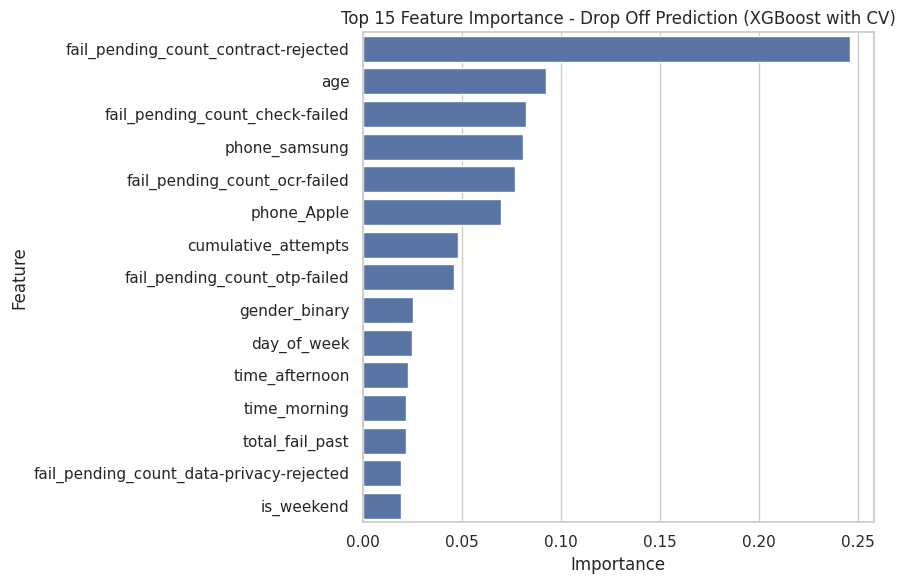

✅ Top 15 features:
                                     Feature  Importance
12      fail_pending_count_contract-rejected    0.245649
0                                        age    0.092237
13           fail_pending_count_check-failed    0.082163
19                             phone_samsung    0.081089
10             fail_pending_count_ocr-failed    0.076940
15                               phone_Apple    0.069714
3                        cumulative_attempts    0.048045
8              fail_pending_count_otp-failed    0.046121
14                             gender_binary    0.025580
2                                day_of_week    0.024844
20                            time_afternoon    0.023069
22                              time_morning    0.021901
4                            total_fail_past    0.021585
9   fail_pending_count_data-privacy-rejected    0.019357
7                                 is_weekend    0.019241

📊 Đánh giá mô hình - Drop Off Prediction:
      Metric  Mean Score
0

In [188]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user  # Đầu vào đã tạo trước đó
y = df_user['drop_off']  # Target đã tạo (1: drop-off, 0: thành công)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (XGBoost with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction:")
print(cv_summary)


In [189]:
!pip install shap
import shap
import matplotlib.pyplot as plt

# final_model: mô hình XGBoost đã được fit
# X_user: tập dữ liệu đầu vào (không chứa drop_off)
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_user)


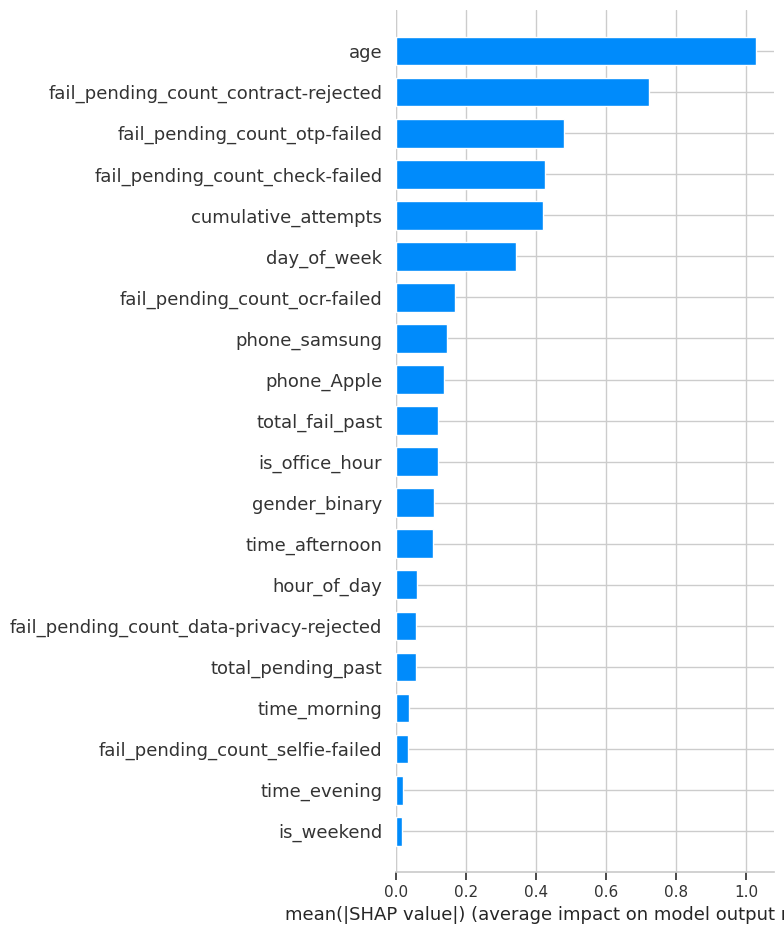

In [190]:
shap.summary_plot(shap_values, X_user, plot_type='bar')


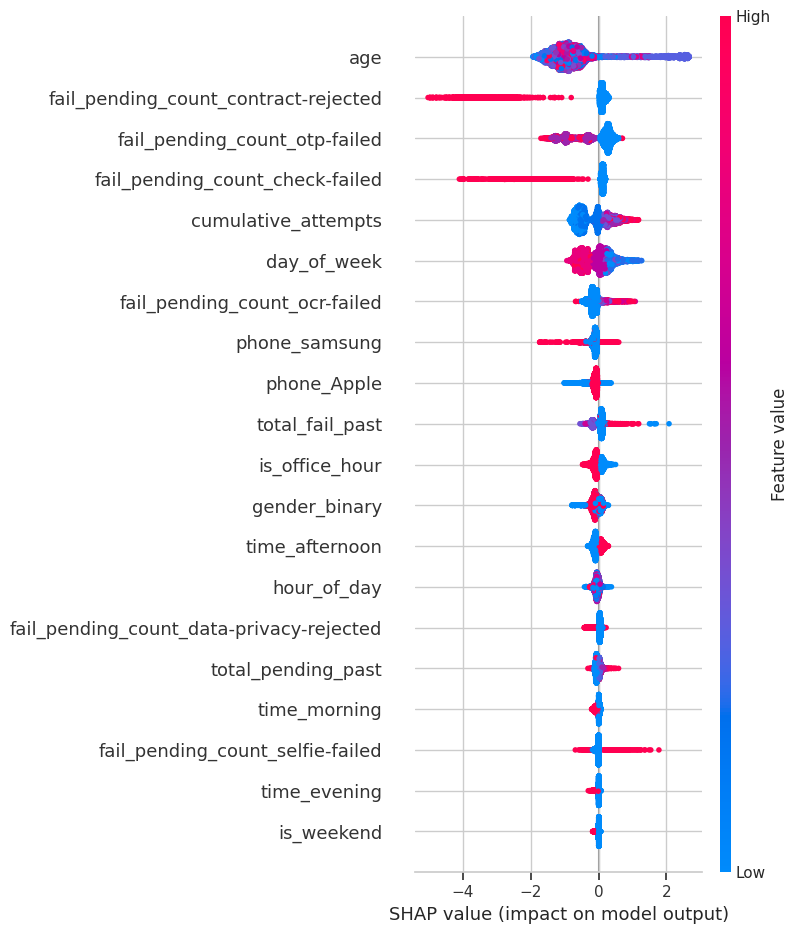

In [191]:
shap.summary_plot(shap_values, X_user)


## Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': None}
📈 CV score mean: 0.9074


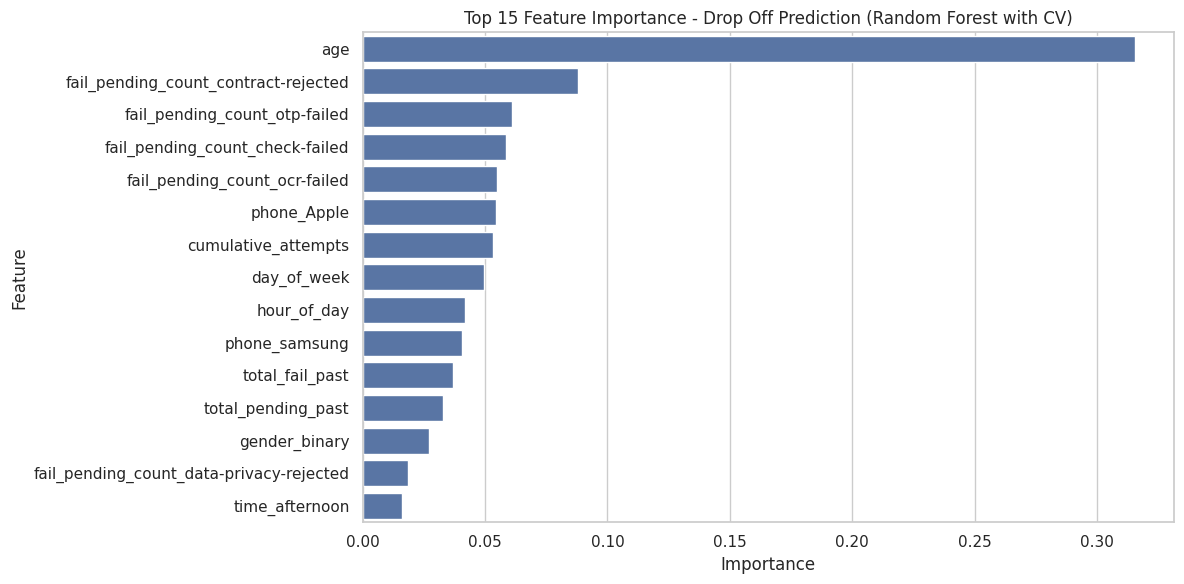

✅ Top 15 features:
                                     Feature  Importance
0                                        age    0.315692
12      fail_pending_count_contract-rejected    0.088045
8              fail_pending_count_otp-failed    0.060780
13           fail_pending_count_check-failed    0.058604
10             fail_pending_count_ocr-failed    0.054927
15                               phone_Apple    0.054351
3                        cumulative_attempts    0.053226
2                                day_of_week    0.049367
1                                hour_of_day    0.041627
19                             phone_samsung    0.040721
4                            total_fail_past    0.036928
5                         total_pending_past    0.032794
14                             gender_binary    0.026909
9   fail_pending_count_data-privacy-rejected    0.018299
20                            time_afternoon    0.015907

📊 Đánh giá mô hình - Drop Off Prediction (Random Forest):
      Metr

In [192]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user
y = df_user['drop_off']

# 2. SMOTE + Random Forest Pipeline
rf = RandomForestClassifier(
    n_jobs=-1,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 7, 10, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_rf = best_model.named_steps['rf']
final_rf.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (Random Forest with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction (Random Forest):")
print(cv_summary)


## LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 8543, number of negative: 8543
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003745 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2153
[LightGBM] [Info] Number of data points in the train set: 17086, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Best hyperparameters:
{'lgb__subsample': 0.6, 'lgb__num_leaves': 31, 'lgb__n_estimators': 200, 'lgb__max_depth': 10, 'lgb__learning_rate': 0.01, 'lgb__colsample_bytree': 1.0}
📈 CV score mean: 0.9105
[LightGBM] [Info] Number of positive: 8543, number of negative: 8543
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And i

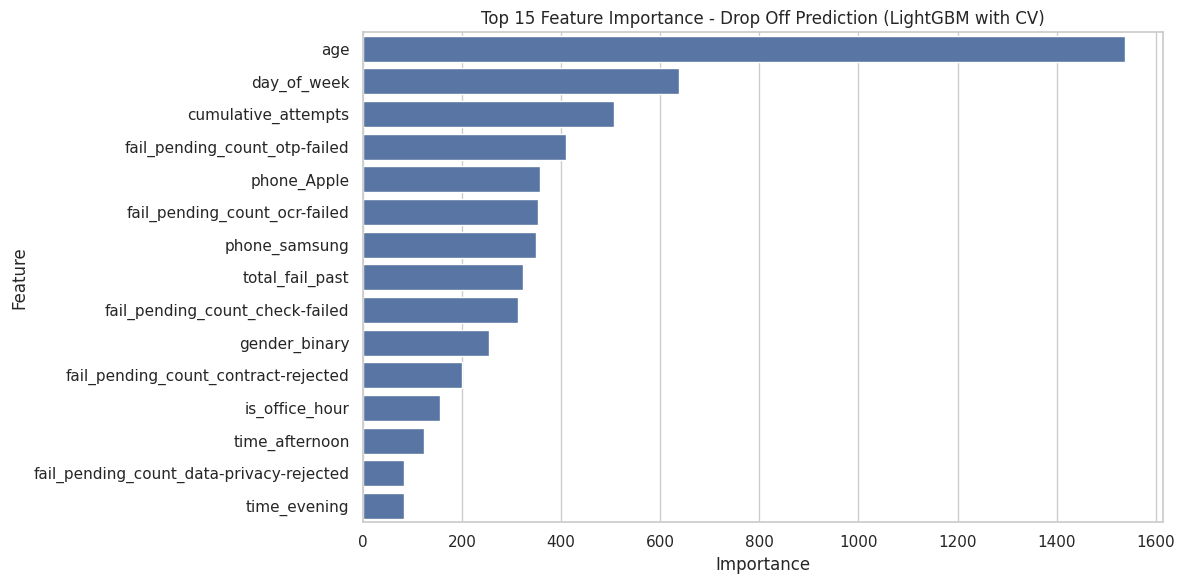

✅ Top 15 features:
                                     Feature  Importance
0                                        age        1538
2                                day_of_week         638
3                        cumulative_attempts         506
8              fail_pending_count_otp-failed         411
15                               phone_Apple         357
10             fail_pending_count_ocr-failed         353
19                             phone_samsung         350
4                            total_fail_past         323
13           fail_pending_count_check-failed         313
14                             gender_binary         255
12      fail_pending_count_contract-rejected         200
6                             is_office_hour         155
20                            time_afternoon         124
9   fail_pending_count_data-privacy-rejected          84
21                              time_evening          84
[LightGBM] [Info] Number of positive: 6834, number of negative: 6834


In [193]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
X = X_user
y = df_user['drop_off']

# 2. SMOTE + LightGBM Pipeline
lgb = LGBMClassifier(
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [5, 7, 10, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 63],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_lgb = best_model.named_steps['lgb']
final_lgb.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Drop Off Prediction (LightGBM with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction (LightGBM):")
print(cv_summary)


In [196]:
!pip install shap
import shap
import matplotlib.pyplot as plt

# final_lgb: mô hình LightGBM đã được fit
# X_user: tập dữ liệu đầu vào (không chứa drop_off)
explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer.shap_values(X_user)


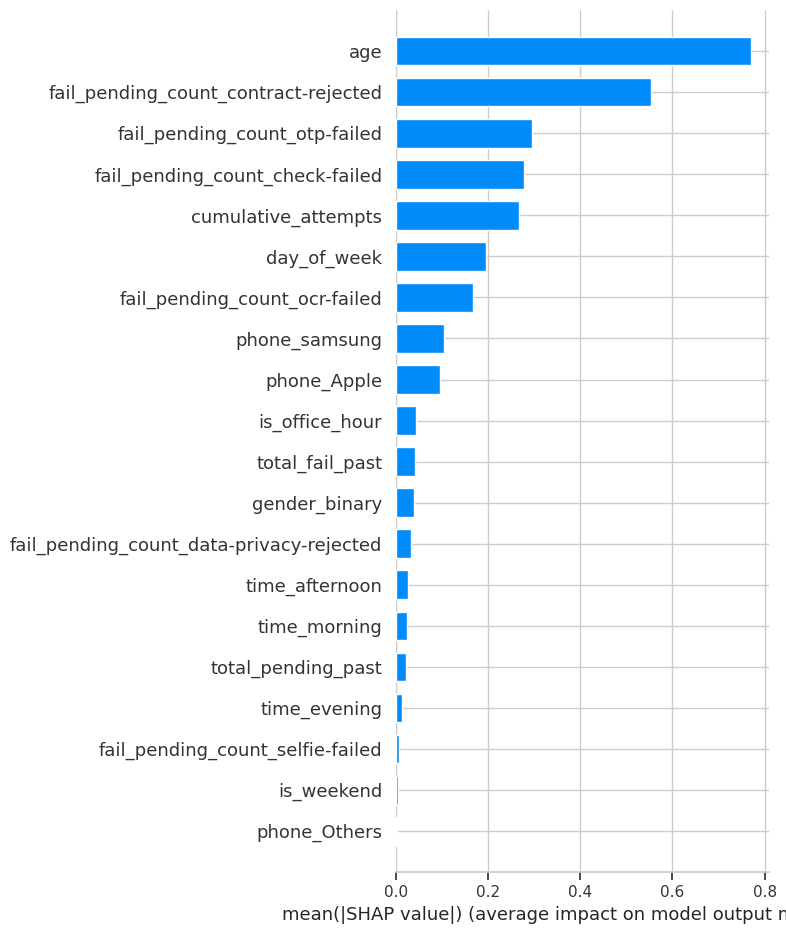

In [198]:
shap.summary_plot(shap_values, X_user, plot_type='bar')


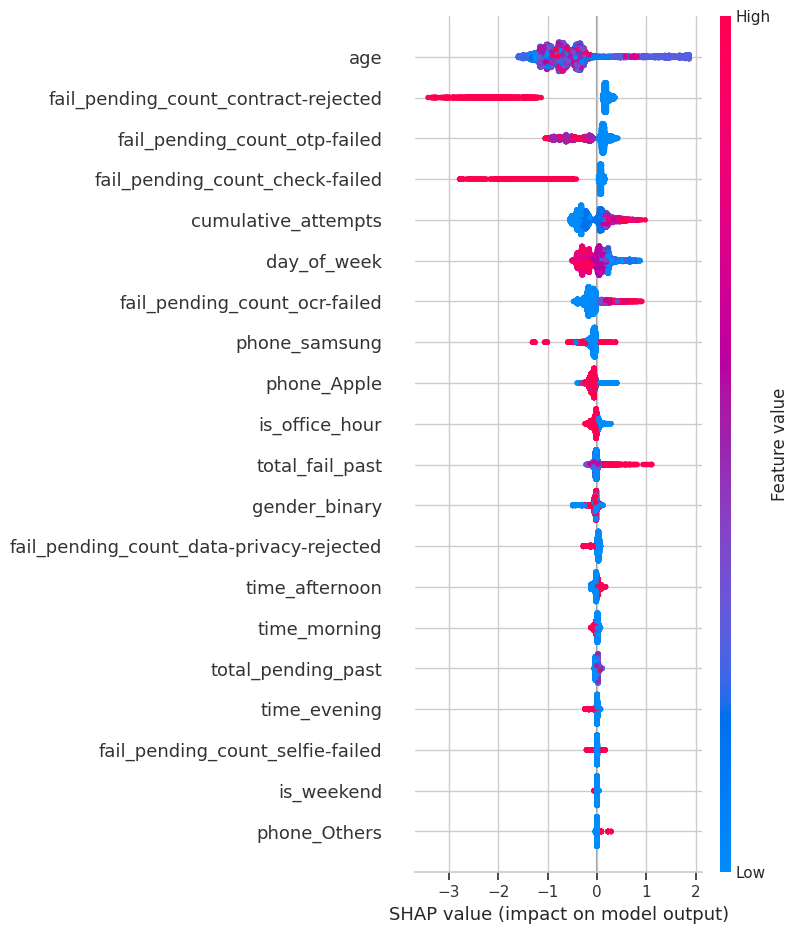

In [199]:
shap.summary_plot(shap_values, X_user)

## CatBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.0 MB/s eta 0:00:00
Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'cat__learning_rate': 0.01, 'cat__l2_leaf_reg': 5, 'cat__iterations': 200, 'cat__depth': 10, 'cat__border_count': 64}
📈 CV score mean: 0.9050


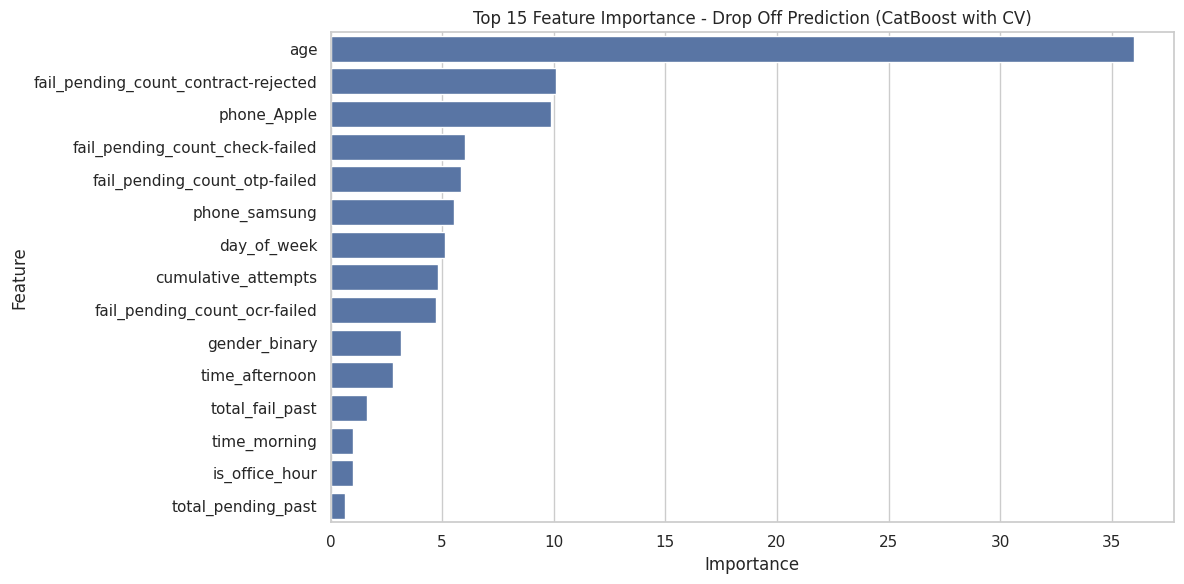

✅ Top 15 features:
                                 Feature  Importance
0                                    age   35.985164
12  fail_pending_count_contract-rejected   10.108630
15                           phone_Apple    9.859396
13       fail_pending_count_check-failed    6.035165
8          fail_pending_count_otp-failed    5.829434
19                         phone_samsung    5.533197
2                            day_of_week    5.109799
3                    cumulative_attempts    4.829934
10         fail_pending_count_ocr-failed    4.716732
14                         gender_binary    3.137246
20                        time_afternoon    2.795238
4                        total_fail_past    1.623040
22                          time_morning    1.019212
6                         is_office_hour    1.016648
5                     total_pending_past    0.663703

📊 Đánh giá mô hình - Drop Off Prediction (CatBoost):
      Metric  Mean Score
0    ROC AUC    0.905018
1   Accuracy    0.908941
2   

In [201]:
!pip install catboost
import pandas as pd
from catboost import CatBoostClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. Chuẩn bị dữ liệu
# =========================================================

X = X_user.copy()
y = df_user['drop_off'].copy()


# =========================================================
# 2. SMOTE + CatBoost Pipeline
# Giữ nguyên flow như LightGBM, chỉ đổi model
# =========================================================

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('cat', cat)
])


# =========================================================
# 3. Hyperparameter space cho CatBoost
# =========================================================

param_dist = {
    'cat__iterations': [100, 200, 300],
    'cat__depth': [4, 6, 8, 10],
    'cat__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'cat__l2_leaf_reg': [1, 3, 5, 7, 10],
    'cat__border_count': [32, 64, 128]
}


# =========================================================
# 4. RandomizedSearchCV
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)


# =========================================================
# 5. Kết quả tổng hợp
# =========================================================

best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")


# =========================================================
# 6. Final model để phân tích feature importance
# =========================================================

final_cat = best_model.named_steps['cat']

X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X, y)

final_cat.fit(X_resampled, y_resampled)


# =========================================================
# 7. Feature importance
# =========================================================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_cat.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)
plt.title("Top 15 Feature Importance - Drop Off Prediction (CatBoost with CV)")
plt.tight_layout()
plt.show()

print("✅ Top 15 features:")
print(importance_df.head(15))


# =========================================================
# 8. Cross Validation mở rộng
# =========================================================

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Drop Off Prediction (CatBoost):")
print(cv_summary)